# Dynamical clustering 


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, browse_swot_2km
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U

_______
# Data

In [107]:
# alternative functions (more variables)

dtypes = {'drifter_id':str}
def prepared_drifters(drifter_key) : 
    dfr = pd.read_csv(DRIFTER[drifter_key], parse_dates=['datetime'], dtype=dtypes).set_index('row_number')
    dfr['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dfr.latitude * np.pi / 180)
    dfr['core']= -dfr.f * dfr.velocity_north
    dfr['corn']= dfr.f * dfr.velocity_east
    dfr = dfr.rename(columns = {'acceleration_north':'accn', 'acceleration_east':'acce'})
    return dfr
    
def prepared_alti(alti_key, ggd_var=['duacs_ssha_karin_2_filtered','duacs_ssha_karin_2_calibrated','cvl_mean_dynamic_topography_cnes_cls_22','cvl_ocean_tide_fes_2022']) :
    dfs = pd.read_csv(ALTI[alti_key]).set_index('row_number')
    dfs['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dfs.latitude * np.pi / 180)
    dfs['ggde_fromduacsv'] = dfs.f * dfs.duacs_speed_meridional_abs
    dfs['ggdn_fromduacsv'] = -dfs.f *dfs.duacs_speed_zonal_abs
    dfs = dfs[['ggde_'+v for v in ggd_var]+['ggdn_'+v for v in ggd_var]+['ggde_fromduacsv', 'ggdn_fromduacsv']]
    dfs['ggde_etaf'] = dfs.ggde_duacs_ssha_karin_2_filtered + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggde_cvl_ocean_tide_fes_2022
    dfs['ggdn_etaf'] = dfs.ggdn_duacs_ssha_karin_2_filtered + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggdn_cvl_ocean_tide_fes_2022
    dfs['ggde_adtf'] = dfs.ggde_duacs_ssha_karin_2_filtered + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22
    dfs['ggdn_adtf'] = dfs.ggdn_duacs_ssha_karin_2_filtered + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22
    dfs['ggde_etac'] = dfs.ggde_duacs_ssha_karin_2_calibrated + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggde_cvl_ocean_tide_fes_2022
    dfs['ggdn_etac'] = dfs.ggdn_duacs_ssha_karin_2_calibrated + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggdn_cvl_ocean_tide_fes_2022
    dfs['ggde_adtc'] = dfs.ggde_duacs_ssha_karin_2_calibrated + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22
    dfs['ggdn_adtc'] = dfs.ggdn_duacs_ssha_karin_2_calibrated + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22
    return dfs#.rename(columns ={v : v+'_' +alti_key for v in dfs})
    
def prepared_wd(wd_key): 
    dfw = pd.read_csv(WD[wd_key]).set_index('row_number')
    #dfw = dfw[[v for v in dfw if ('wde' in v or 'wdn' in v)]]
    return dfw.drop(columns = ['longitude', 'latitude'])#.rename(columns ={v : v+'_' +wd_key for v in dfw})



In [108]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),]

DS = dataset_coloc_combs(comb_list, nearest =False).dropna('row_number').drop_sel(row_number = err_acc)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
DS50 = DS.where(DS.depth==50, drop=True)
DS100 = DS.where(DS.depth==100, drop=True)

df = DS.isel(id_comb=0).to_dataframe()
ds = df.to_xarray()

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5


In [109]:
# Mean flow, HF flow and mean wind

df0 = pd.concat([prepared_drifters('nofilter'), prepared_alti('swot2kmnaive'), prepared_wd('era5')], axis=1)
df_ = df0[df0.drifter_id == '300534060315840']
def roll_mean_one_id(df, window):
    df_ = df.reset_index().set_index('datetime').sort_index()
    df_['meanflowe'] = abs(df_.velocity_east.rolling(window=pd.Timedelta(window)).mean())
    df_['meanflown'] = abs(df_.velocity_north.rolling(window=pd.Timedelta(window)).mean())
    df_['meanwinde'] = abs(df_.iews.rolling(window=pd.Timedelta(window)).mean())
    df_['meanwindn'] = abs(df_.inss.rolling(window=pd.Timedelta(window)).mean())
    df_['hfe'] = abs(df_.velocity_east.rolling(window=pd.Timedelta(window)).std())
    df_['hfn'] = abs(df_.velocity_north.rolling(window=pd.Timedelta(window)).std())
    return df_.reset_index().set_index('row_number')[['datetime', 'drifter_id', 'cycle_date', 'longitude', 'latitude', 'pass_number', 'cycle_number', 'meanwinde', 'meanwindn', 'meanflowe', 'meanflown', 'hfe', 'hfn']]
    
roll_mean_one_id(df_, window = pd.Timedelta('1d'))

DF = []
for id_ in df0.drifter_id.unique() :
    df_ = df0[df0.drifter_id == id_]
    DF.append(roll_mean_one_id(df_, window = pd.Timedelta('1d')))
df1 = pd.concat(DF)
ds1 = df1.to_xarray().set_coords(['datetime', 'drifter_id', 'cycle_date','longitude', 'latitude', 'pass_number', 'cycle_number','longitude', 'latitude',])

In [110]:
df1.columns

Index(['datetime', 'drifter_id', 'cycle_date', 'longitude', 'latitude',
       'pass_number', 'cycle_number', 'meanwinde', 'meanwindn', 'meanflowe',
       'meanflown', 'hfe', 'hfn'],
      dtype='object')

______
# Clustering

In [111]:
from sklearn.cluster import KMeans 

In [121]:
# CHOOSE DEPTH
depth = 0
dsd = ds1.sel(row_number = df[df.depth==15].index)
dfc = dsd.to_dataframe().dropna()

In [122]:
X = dfc[['meanflowe', 'hfe', 'meanwinde', 'meanflown', 'hfn', 'meanwindn']].dropna()
nc = 4

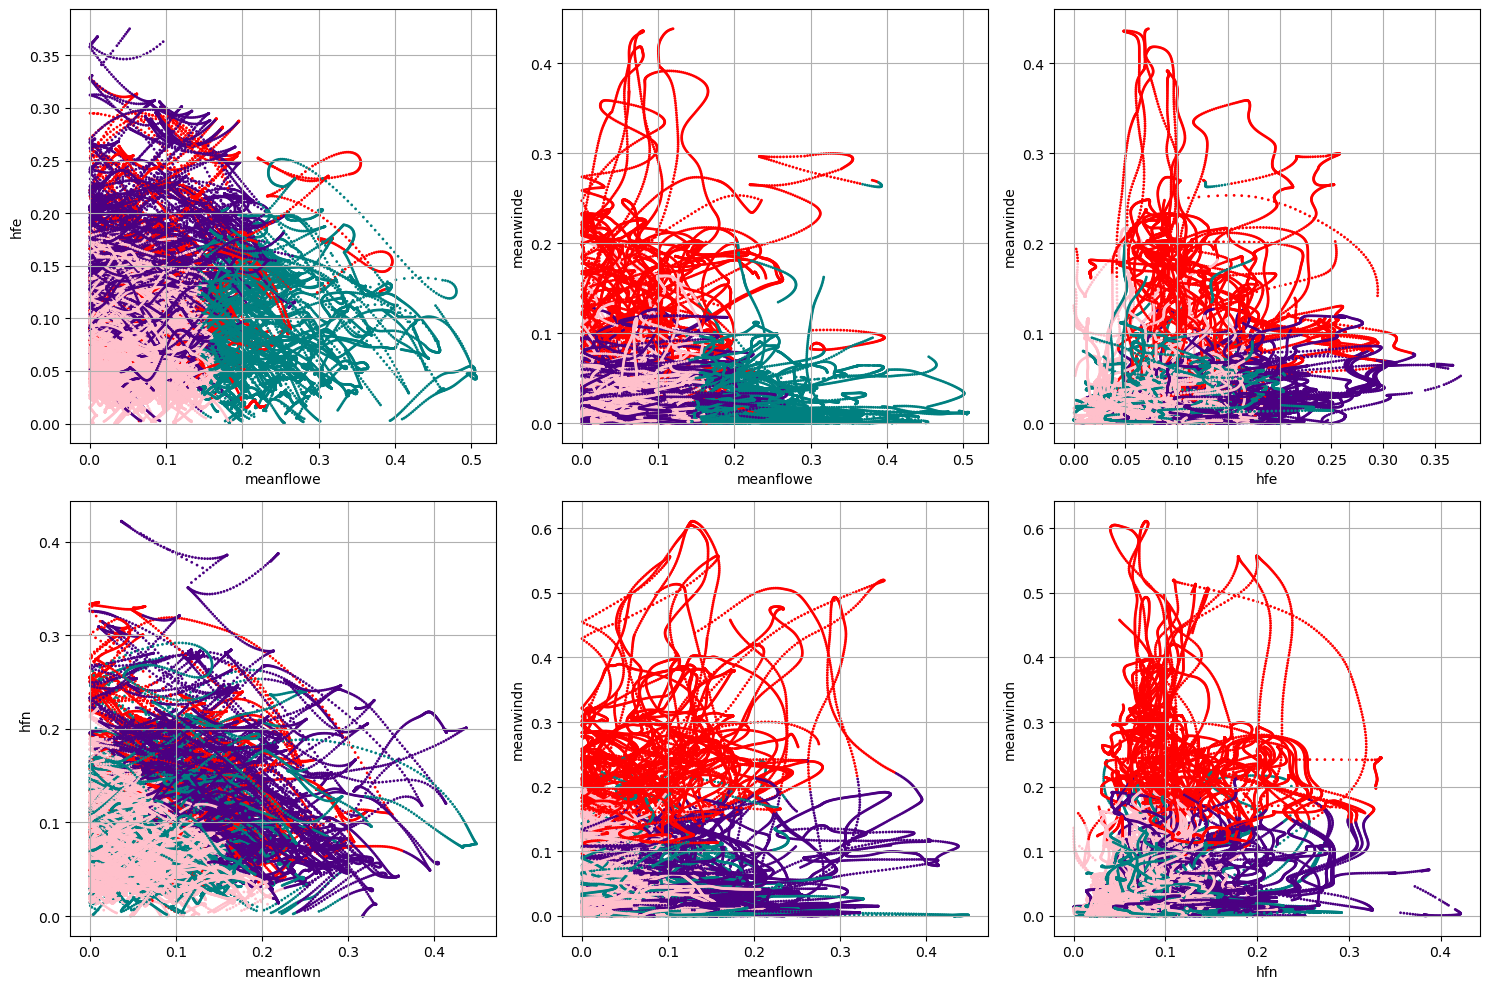

In [123]:
from sklearn.cluster import KMeans

common_params = {
    "n_init": "auto",
}
cmap='viridis'

fig, axs = plt.subplots(2,3, figsize=(15,10))
axs = axs.flatten()
s=1
y_pred = KMeans(n_clusters=nc, **common_params).fit_predict(X)

color = {0:'teal', 1:'indigo', 2:'red', 3:'pink', 4:'orange'}

c = np.where(y_pred==0, color[0], y_pred)
for i in range(1,nc) :
    c = np.where(y_pred==i, color[i], c)

dfc.plot.scatter('meanflowe', 'hfe', ax = axs[0], s=s, c=c)
dfc.plot.scatter('meanflowe', 'meanwinde', ax = axs[1], s=s, c=c)
dfc.plot.scatter('hfe', 'meanwinde', ax = axs[2], s=s, c=c)

dfc.plot.scatter('meanflown', 'hfn', ax = axs[3], s=s, c=c)
dfc.plot.scatter('meanflown', 'meanwindn', ax = axs[4], s=s, c=c)
dfc.plot.scatter('hfn', 'meanwindn', ax = axs[5], s=s, c=c)

for ax in axs:
    ax.grid()
    
fig.tight_layout()

Text(0.5, 0.92, 'Meridional')

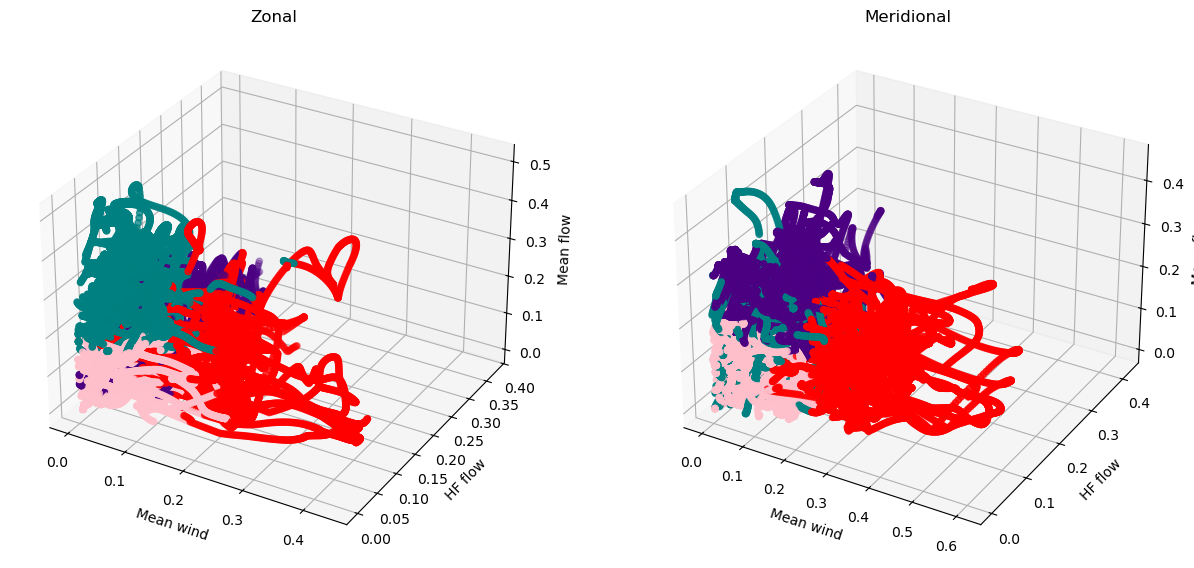

In [124]:
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(xs=dfc.meanwinde, ys =dfc.hfe, zs=dfc.meanflowe, c=c)
ax.set_title('Zonal')
ax.set_xlabel('Mean wind')
ax.set_ylabel('HF flow')
ax.set_zlabel('Mean flow')
ax = fig.add_subplot(122, projection='3d')
ax.scatter(xs=dfc.meanwindn, ys =dfc.hfn, zs=dfc.meanflown, c=c)
ax.set_xlabel('Mean wind')
ax.set_ylabel('HF flow')
ax.set_zlabel('Mean flow')
ax.set_title('Meridional')
#fig.tight_layout()

- 0-teal : low wind - low mean flow - low HF flow
- 1-indigo : high wind
- 2-red : low-wind - high zonal mean flow -low HF flow
- 3-pink : low wind - low mean flow - high HF flow 

In [125]:
color = {0:'teal', 1:'indigo', 2:'red', 3:'pink', 4:'orange'}

In [126]:
dfc['cluster'] = y_pred
#df = df.reset_index().set_index(['pass_number','cycle_number','drifter_id'])
#df['cluster']= dfc.reset_index().set_index(['pass_number','cycle_number','drifter_id'])['cluster']
#df = df.reset_index().set_index('row_number')

In [118]:
dfc

,datetime,drifter_id,cycle_date,longitude,latitude,pass_number,cycle_number,meanwinde,meanwindn,meanflowe,meanflown,hfe,hfn,cluster
row_number,,,,,,,,,,,,,,
1,2023-04-01 12:00:00,300534060315840,2023-04-01 23:42:32.696536000,4.812432,42.221430,3,478,0.193788,0.158837,0.064724,0.098624,0.002433,0.005040,2
2,2023-04-01 12:10:00,300534060315840,2023-04-01 23:42:32.696536000,4.812916,42.221930,3,478,0.190727,0.155216,0.066192,0.095170,0.003070,0.006964,2
3,2023-04-01 12:20:00,300534060315840,2023-04-01 23:42:32.696536000,4.813418,42.222394,3,478,0.187415,0.151487,0.067420,0.091850,0.003510,0.008742,2
4,2023-04-01 12:30:00,300534060315840,2023-04-01 23:42:32.696536000,4.813933,42.222825,3,478,0.184005,0.147717,0.068422,0.088691,0.003776,0.010355,2
5,2023-04-01 12:40:00,300534060315840,2023-04-01 23:42:32.696536000,4.814456,42.223226,3,478,0.180544,0.143928,0.069212,0.085716,0.003893,0.011784,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383258,2023-07-10 06:10:00,300534060015760,2023-07-09 18:56:21.868455616,2.417785,39.788394,16,577,0.004790,0.008606,0.038542,0.095014,0.107107,0.106440,3
383259,2023-07-10 06:20:00,300534060015760,2023-07-09 18:56:21.868455616,2.416881,39.788885,16,577,0.005213,0.008740,0.036655,0.096186,0.107657,0.105500,3
383260,2023-07-10 06:30:00,300534060015760,2023-07-09 18:56:21.868455616,2.415948,39.789399,16,577,0.005621,0.008871,0.034789,0.097335,0.108253,0.104624,3


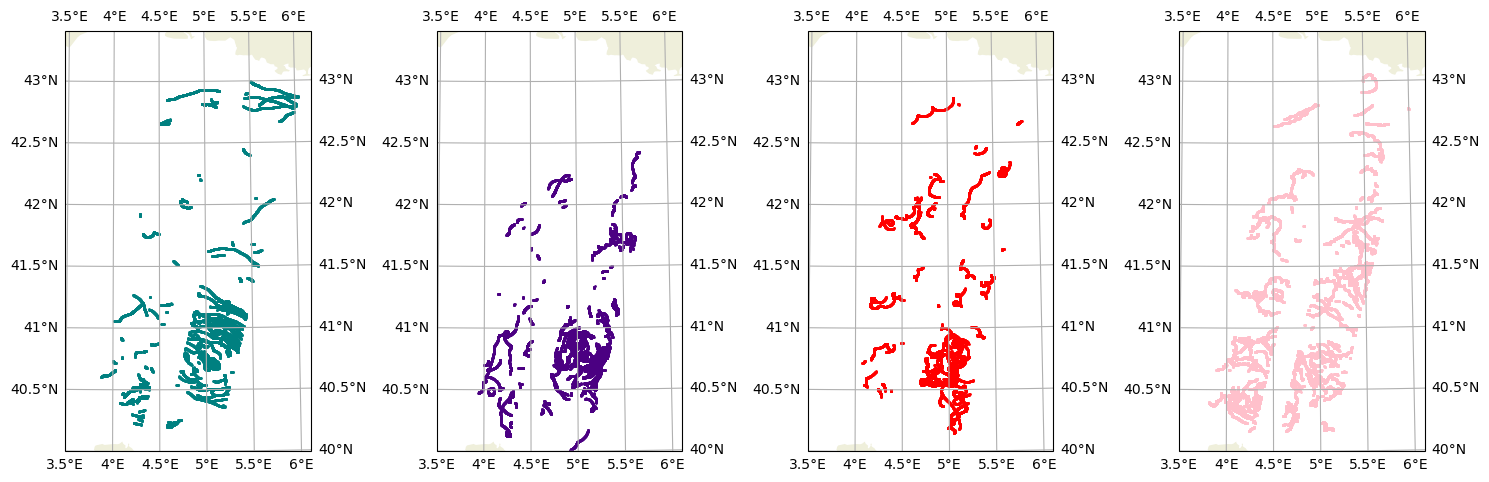

In [127]:
fig = plt.figure(figsize=(15,15))
#bbox =[2.7, 5.1, 36.6, 40]
#bbox = [0.9, 3.7, 37.7, 41.25]
bbox = [3.5, 6.1, 40, 43.4]
for i in range(nc) : 
    ax = fig.add_subplot(1,nc,i+1, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    dfc[dfc.cluster==i].plot.scatter(x='longitude', y='latitude',ax=ax, transform=crs, s=1, c=color[i])
    gl = ax.gridlines(draw_labels=True,)
    ax.add_feature(cfeature.LAND,)
    ax.set_extent(bbox)

fig.tight_layout()

_____
# STORE

In [129]:
dfc.to_csv(os.path.join(zarr_dir, f'cluster_{nc}_{depth}m.csv'))